# Notebook 05 — Perbandingan Antar Varian

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/05_comparison.ipynb)

**Anggota yang menggabungkan:** _isi nama di sini_

---

Notebook ini **membaca file CSV history** yang sudah dihasilkan oleh keempat varian (file ada di folder `results/`), lalu menggabungkannya menjadi tabel ringkasan dan grafik komparatif.

**Prasyarat:** keempat anggota sudah commit notebook varian masing-masing dan file `results/*.csv` sudah ada di repo.

## 1. Setup

In [3]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-kelompok_tiga'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into 'repo'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 64 (delta 21), reused 9 (delta 9), pack-reused 27 (from 4)
Receiving objects: 100% (64/64), 196.85 KiB | 9.37 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github', 'results']


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = 'results'
files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.csv')])
print('Ditemukan file:', files)


Ditemukan file: ['03_mlp_tanh.csv']


## 2. Gabungkan semua history

In [5]:
dfs = []
for f in files:
    df = pd.read_csv(os.path.join(RESULTS_DIR, f))
    dfs.append(df)
all_history = pd.concat(dfs, ignore_index=True)
all_history.head()


,accuracy,loss,val_accuracy,val_loss,epoch,variant
0,0.604167,0.970376,0.583333,0.936943,1,03_mlp_tanh
1,0.687500,0.856065,0.625000,0.854114,2,03_mlp_tanh
2,0.697917,0.762400,0.666667,0.786089,3,03_mlp_tanh
3,0.802083,0.686949,0.750000,0.731074,4,03_mlp_tanh
4,0.833333,0.626863,0.750000,0.686574,5,03_mlp_tanh


## 3. Tabel akurasi akhir per varian

In [6]:
final = all_history.sort_values('epoch').groupby('variant').tail(1)
summary = final[['variant', 'loss', 'val_loss', 'accuracy', 'val_accuracy']]
summary = summary.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
summary


,variant,loss,val_loss,accuracy,val_accuracy
0,03_mlp_tanh,0.113794,0.126471,0.96875,0.958333


## 4. Plot validation accuracy semua varian

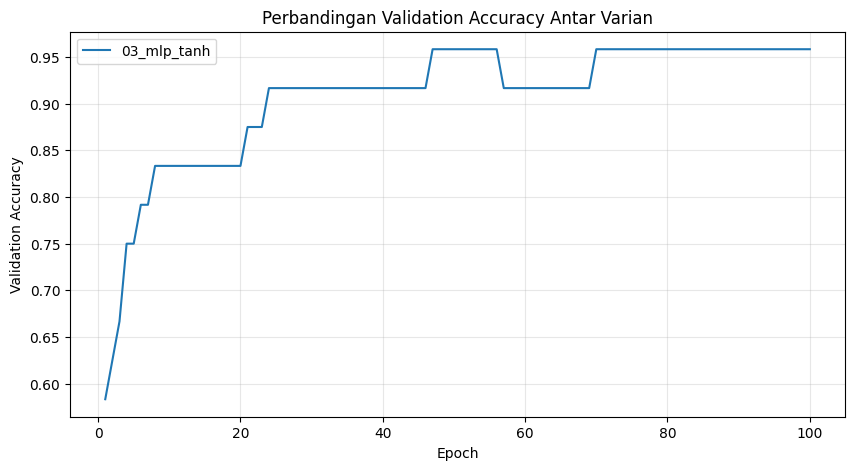

In [7]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_accuracy'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Perbandingan Validation Accuracy Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Plot validation loss semua varian

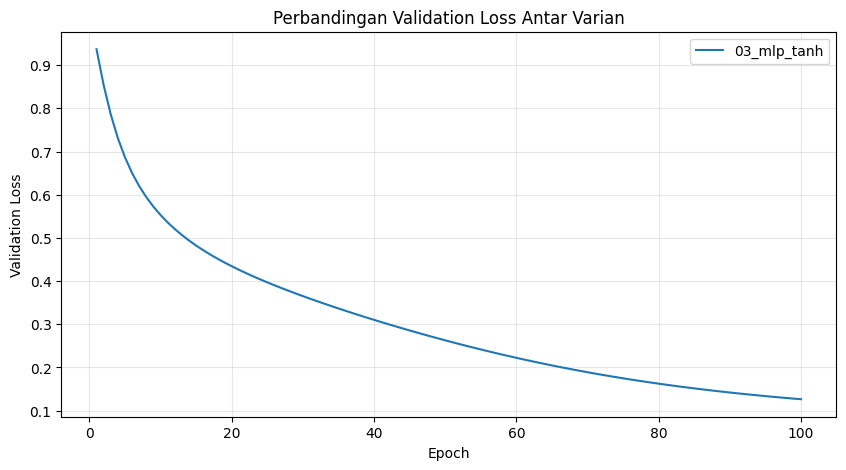

In [8]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_loss'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Perbandingan Validation Loss Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Diskusi kelompok
Berdasarkan tabel dan grafik di atas, **isi `docs/REPORT.md`** dengan analisis kelompok. Jangan hanya mendeskripsikan grafik — kaitkan dengan teori di slide kuliah.